# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A model is linear if it uses known data to predict a single line, which describes the Y of unknown observations based on their other attributes.


2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

The coefficient is the difference in means in Y of the 1 group and the 0 group.

3. Can linear regression be used for classification? Explain why, or why not.

Linear regression can be used for classification, but we would need to assign each category to a numerical value of our Y variable (e.g. red = 0, blue = 1, orange = 2), or have multiple Y dummy variables (we first regress on IsRed as Y, then IsBlue, etc.). However, even then we might get weird values (e.g. if we have red = 0, blue = 1, orange = 2, we might get 1.50 and be completely unsure about what to do with that).

4. What are signs that your linear model is over-fitting?

This would be if small changes in the data change signs or coefficient sizes drastically, or train error is much smaller than test error.

5. Clearly explain multi-colinearity using the two-stage least squares technique.

Say we regress y on two variables, x1 and x2, that are very highly correlated with each other and y. Those variables cancel each other out (are multi-colinear) -- providing very high variance. We can get rid of this using 2SLS. There, in the 2nd stage, we would reg residual of y on the residual of x1/x2, which makes it hard for either variable to explain y.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

You can add things like ^2 or ^3, logs, and other transforms to account for this. Note that this changes the interpretation of the coefficients!

7. What is the interpretation of the slope coefficient in a linear regression?

Assuming $Y = \beta_0 + \beta_1 X$ (I know LaTeX I swear this is not AI writing this), a one unit change in X creates a $\beta_1$ unit change in Y.

8. Compare the train/test split and $k$-fold cross validation.

A train test split just uses a single split. Meanwhile, k-fold cross validation divides the data into k parts, trains the model k times, and each time uses a different fold to validate while training on the other folds. This gives a more stable/reliable estimate than a single train-test split.

9. How is the $k$ in $k$-fold cross validation typically selected?

Usually, we just use k=5 or k=10, which is a good compromise between stability & how long it takes to compute.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.

In [53]:
# Get data
! git clone https://github.com/ds4e/get_data
%run ./get_data/get_data.py

# Import libraries
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import PolynomialFeatures

fatal: destination path 'get_data' already exists and is not an empty directory.


<Figure size 640x480 with 0 Axes>

In [46]:
# Load data first
neighborhood = pd.read_csv("./data/airbnb_hw.csv", encoding = "utf-8").rename(columns=lambda c: c.strip())
neighborhood.dtypes

,0
Host Id,int64
Host Since,object
Name,object
Neighbourhood,object
Property Type,object
Review Scores Rating (bin),float64
Room Type,object
Zipcode,float64
Beds,float64
Number of Records,int64


In [58]:
# Clean types
neighborhood['Price'] = pd.to_numeric(neighborhood['Price'], errors='coerce')
neighborhood['Review Scores Rating'] = pd.to_numeric(
    neighborhood['Review Scores Rating'],
    errors='coerce'
)

avg_neighborhood = (
    neighborhood.groupby('Neighbourhood')[['Price', 'Review Scores Rating']]
    .mean()
)
neighborhood = neighborhood.dropna()

# Average prices & scores by neighborhood
avg_neighborhood = (neighborhood.groupby('Neighbourhood')[['Price', 'Review Scores Rating']]
         .mean())
print('Average prices by neighborhood:')
print(avg_neighborhood)

Average prices by neighborhood:
                    Price  Review Scores Rating
Neighbourhood                                  
Bronx           75.195349             91.706977
Brooklyn       125.246287             92.345729
Manhattan      178.339252             91.792846
Queens          96.813452             91.505711
Staten Island   95.516129             91.322581


Manhattan is the most expensive on average.

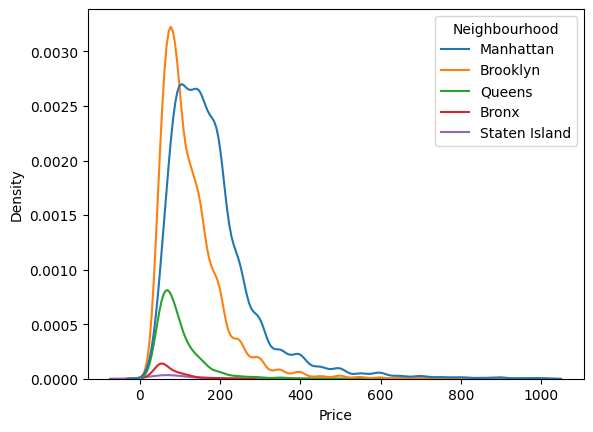

/tmp/ipykernel_2742/2009733302.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neighborhood['Log Price'] = np.log(neighborhood['Price'])


<Axes: xlabel='Log Price', ylabel='Density'>

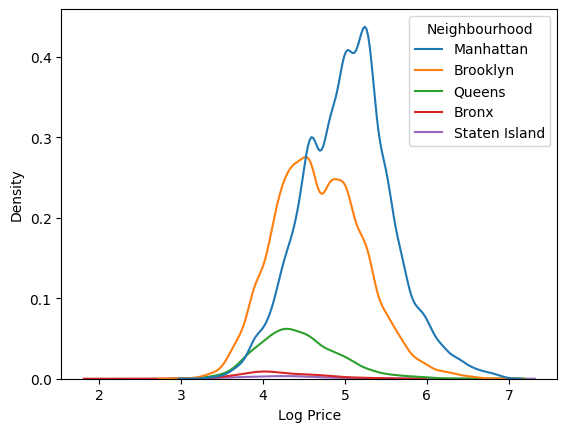

In [59]:
# KDE of price:
sns.kdeplot(x=neighborhood['Price'],hue=neighborhood['Neighbourhood'])
plt.show()

# KDE of log price:
neighborhood['Log Price'] = np.log(neighborhood['Price'])
sns.kdeplot(x=neighborhood['Log Price'],hue=neighborhood['Neighbourhood'])

2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?

In [63]:
neighborhood_dummies = pd.get_dummies(neighborhood['Neighbourhood'])
price = neighborhood['Price']

# I will drop the intercept of the regression -- dropping a dummy feels a little wrong to me
price_neighborhood_reg = LinearRegression(fit_intercept=False).fit(neighborhood_dummies, price)

coef_table = pd.Series(
    price_neighborhood_reg.coef_,
    index=neighborhood_dummies.columns
)

print(coef_table)


Bronx             75.195349
Brooklyn         125.246287
Manhattan        178.339252
Queens            96.813452
Staten Island     95.516129
dtype: float64


Since we dropped the intercept of the regression, the coefficients are exactly the same as the average prices from part 1 (i.e. effect of switching on Bronx is just its average price, $75).

3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.

In [77]:
Q3_X = neighborhood[['Review Scores Rating']]
Q3_y = neighborhood['Price']

Q3_reg = LinearRegression(fit_intercept=True).fit(Q3_X, y)

print("slope:", Q3_reg.coef_[0])
print("intercept:", Q3_reg.intercept_)


slope: 0.9890868445779194
intercept: 59.799152409413736


For each 1 rating point increase, the average price of an AirBNB rental increases by $0.98.

4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?

In [78]:
scores = neighborhood[['Review Scores Rating']]
price = neighborhood['Price']
neighborhood_dummies = pd.get_dummies(neighborhood['Neighbourhood'])

# Combine predictors
Q4_X = pd.concat([scores, neighborhood_dummies], axis=1)
Q4_y = price

# Fit model (no intercept because full set of dummies)
Q4_reg = LinearRegression(fit_intercept=False).fit(Q4_X, Q4_y)

# Coefficients
coef_table = pd.Series(price_score_reg.coef_, index=Q4_X.columns)

print(coef_table)

Review Scores Rating     1.042837
Bronx                  -20.440108
Brooklyn                28.944716
Manhattan               82.614248
Queens                   1.387883
Staten Island            0.281535
dtype: float64


Once we regress price on both ratings and neighborhood, the coefficients on neighborhood become drastically smaller -- negative for the Bronx, close to 0 for Queens and Staten Island, and a drop of 100 for both Brooklyn and Manhattan. This can be explained by the coefficient on ratings, which isn't substantially larger (\$1.04/rating point vs $0.97), but an average rating of 91-92 multiplied by the 1.04 cofficient equals the 100 drop.

5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?

In [79]:
scores = neighborhood['Review Scores Rating']
price = neighborhood['Price']
neighborhood_dummies = pd.get_dummies(neighborhood['Neighbourhood'])

# Create one rating-based column for each neighborhood
rating_by_neighborhood = neighborhood_dummies.mul(scores, axis=0)

Q5_X = rating_by_neighborhood
Q5_y = price

Q5_reg = LinearRegression(fit_intercept=True).fit(Q5_X, Q5_y)

coef_table = pd.Series(reg.coef_, index=Q5_X.columns)

print("Intercept:", reg.intercept_)
print(coef_table.sort_values())

Intercept: 54.56203024909357
Bronx            0.228063
Staten Island    0.447433
Queens           0.462115
Brooklyn         0.768615
Manhattan        1.346028
dtype: float64


The slopes are very different across neighborhoods. This makes sense because if ratings is the only explanatory variable and we force a singular constant for all neighborhoods, then the gap between the constant and the neighborhood mean (which the coeff is based on) will vary widely for each neighborhood. Of course, this is severe underfitting and the actual causal effect of rating scores on price is much smaller.

6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [82]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

kfold = KFold(n_splits=10, shuffle=True, random_state=100)

# Part 3
scores = cross_val_score(
    Q3_reg, Q3_X, Q3_y,
    cv=kfold,
    scoring="neg_mean_squared_error"
)

print("________Q3________")
print("Fold scores:", scores)
print("Mean score:", np.mean(scores))
print("Median score:", np.median(scores))
print("Std dev:", np.std(scores))
print("Mean MSE:", -np.mean(scores))

# Part 4
scores = cross_val_score(
    Q4_reg, Q4_X, Q4_y,
    cv=kfold,
    scoring="neg_mean_squared_error"
)

print("________Q4________")
print("Fold scores:", scores)
print("Mean score:", np.mean(scores))
print("Median score:", np.median(scores))
print("Std dev:", np.std(scores))
print("Mean MSE:", -np.mean(scores))

# Part 5
scores = cross_val_score(
    Q5_reg, Q5_X, Q5_y,
    cv=kfold,
    scoring="neg_mean_squared_error"
)

print("________Q5________")
print("Fold scores:", scores)
print("Mean score:", np.mean(scores))
print("Median score:", np.median(scores))
print("Std dev:", np.std(scores))
print("Mean MSE:", -np.mean(scores))

________Q3________
Fold scores: [-10515.75658353  -9412.17529715  -9496.79582312 -10596.29709712
  -9335.40283044  -9807.44558808 -10058.32059927 -10111.80855442
  -9604.40168459 -10497.10084211]
Mean score: -9943.55048998295
Median score: -9932.883093676825
Std dev: 456.8083026217033
Mean MSE: 9943.55048998295
________Q4________
Fold scores: [-9484.12479033 -8436.52688321 -8630.49057839 -9815.03873663
 -8459.21022005 -8888.73792584 -9038.47361356 -9166.54640568
 -8582.06790874 -9562.44912688]
Mean score: -9006.366618931188
Median score: -8963.605769702244
Std dev: 466.62252357937695
Mean MSE: 9006.366618931188
________Q5________
Fold scores: [-9486.31088183 -8442.76001856 -8641.72084083 -9809.89109333
 -8458.85459957 -8883.64061663 -9058.65805987 -9189.88557649
 -8571.9277804  -9560.2682373 ]
Mean score: -9010.391770482029
Median score: -8971.149338248091
Std dev: 466.1806296145859
Mean MSE: 9010.391770482029


None of our models are accurate at predicting prices: RMSEs are around 9k, which means that our model is typically off by $\sqrt{9000} = \pm \$95 $. Since our averages are around $100-200, this is a huge error. Our Q4 and Q5 models (around 9k RMSE) with both review scores and neighborhood fare slightly better than our Q3 model (9.9k RMSE), but all of them are rather inaccurate.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?


2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?


3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.


 4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?

2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.

3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?

4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?


5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.

6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?